<a href="https://colab.research.google.com/github/saivishwaksena/DAA/blob/main/RAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers datasets peft accelerate
!pip install -q sentence-transformers faiss-cpu
!pip install -q shap lime gradio
!pip install -q bitsandbytes scipy scikit-learn
!pip install -q matplotlib seaborn wordcloud

print("✅ All packages installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 77.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 20.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.8 MB/s eta 0:00:00
✅ All packages installed!


In [8]:
# Step 1: Download the dataset files
!wget -q "https://huggingface.co/datasets/liar/resolve/refs%2Fconvert%2Fparquet/default/train/0000.parquet" -O train.parquet
!wget -q "https://huggingface.co/datasets/liar/resolve/refs%2Fconvert%2Fparquet/default/validation/0000.parquet" -O val.parquet
!wget -q "https://huggingface.co/datasets/liar/resolve/refs%2Fconvert%2Fparquet/default/test/0000.parquet" -O test.parquet

import pandas as pd

train_df = pd.read_parquet("train.parquet")
val_df   = pd.read_parquet("val.parquet")
test_df  = pd.read_parquet("test.parquet")

print(f"✅ Loaded!")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Columns: {list(train_df.columns)}")
print(f"\nSample claim: {train_df['statement'].iloc[0]}")
print(f"Sample label: {train_df['label'].iloc[0]}")

✅ Loaded!
Train: 10,269 | Val: 1,284 | Test: 1,283
Columns: ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context']

Sample claim: Says the Annies List political group supports third-trimester abortions on demand.
Sample label: 0


In [9]:
for i in range(3):
    row = train_df.iloc[i]
    print(f"\n--- Sample {i+1} ---")
    print(f"Claim:   {row['statement']}")
    print(f"Label:   {row['label']}")
    print(f"Speaker: {row['speaker']}")


--- Sample 1 ---
Claim:   Says the Annies List political group supports third-trimester abortions on demand.
Label:   0
Speaker: dwayne-bohac

--- Sample 2 ---
Claim:   When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.
Label:   1
Speaker: scott-surovell

--- Sample 3 ---
Claim:   Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."
Label:   2
Speaker: barack-obama


In [10]:
# In this version labels are numbers:
# 0 = pants-fire  → FAKE
# 1 = false       → FAKE
# 2 = barely-true → FAKE
# 3 = half-true   → REAL
# 4 = mostly-true → REAL
# 5 = true        → REAL

def simplify_label(label):
    if label in [0, 1, 2]:
        return 0   # FAKE
    elif label in [3, 4, 5]:
        return 1   # REAL
    return -1

for df in [train_df, val_df, test_df]:
    df['binary_label'] = df['label'].apply(simplify_label)
    df['label_name']   = df['binary_label'].map({0: 'FAKE', 1: 'REAL'})
    df['context']      = df['context'].fillna('No context available')
    df['speaker']      = df['speaker'].fillna('Unknown')

train_df = train_df[train_df['binary_label'] != -1].reset_index(drop=True)
val_df   = val_df[val_df['binary_label']     != -1].reset_index(drop=True)
test_df  = test_df[test_df['binary_label']   != -1].reset_index(drop=True)

print("Label counts in training set:")
print(train_df['label_name'].value_counts())
print(f"\n✅ Done! Training samples: {len(train_df):,}")

Label counts in training set:
label_name
FAKE    6087
REAL    4182
Name: count, dtype: int64

✅ Done! Training samples: 10,269


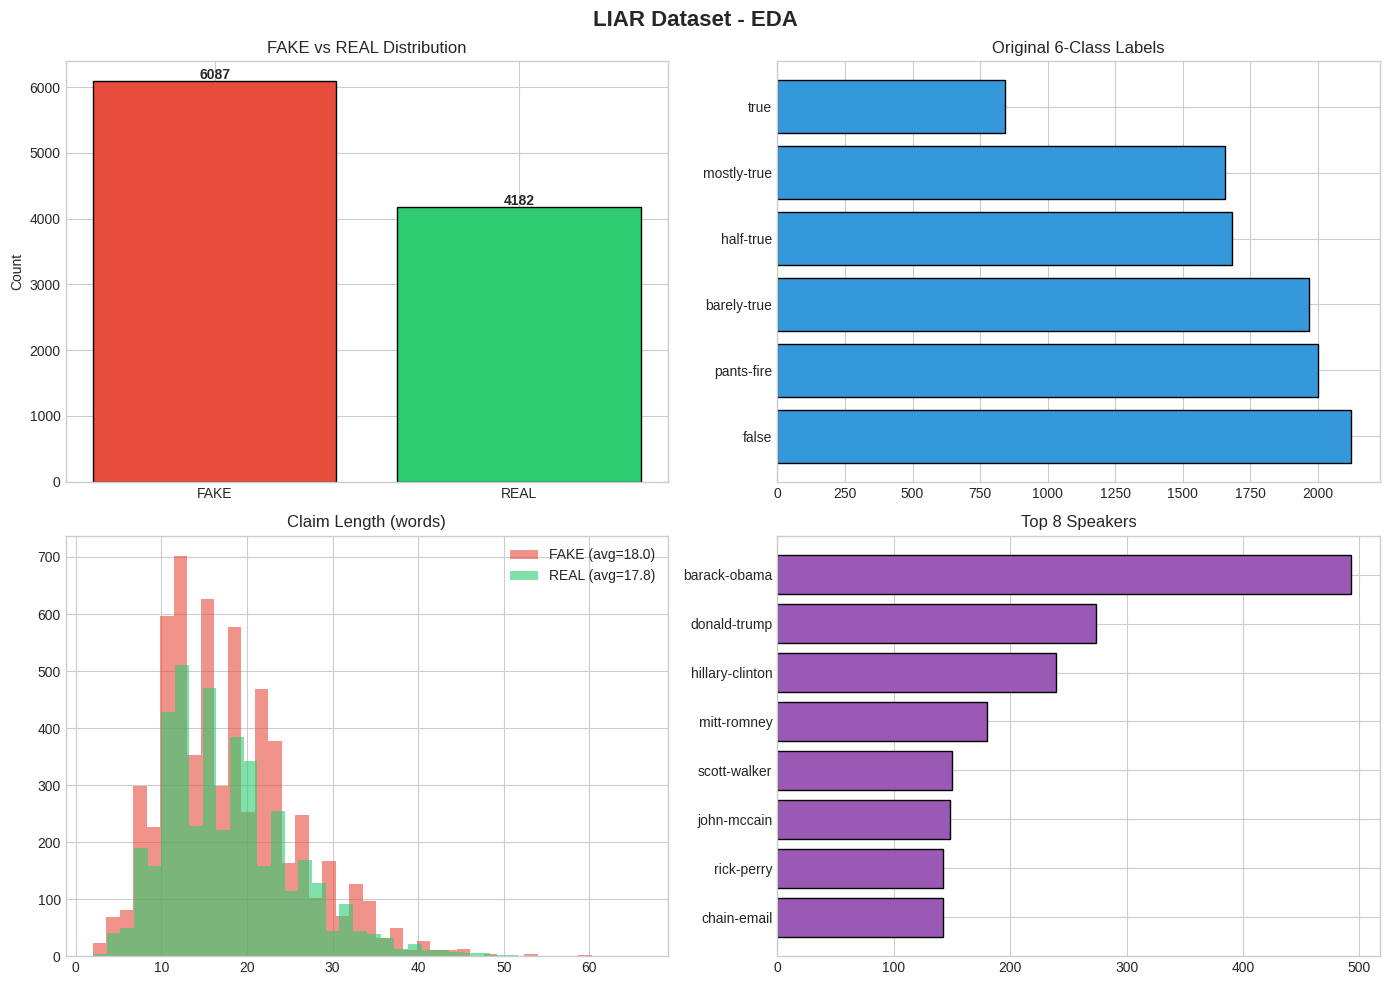

✅ Saved eda_plots.png


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LIAR Dataset - EDA', fontsize=16, fontweight='bold')

# Plot 1: FAKE vs REAL count
ax1 = axes[0, 0]
counts = train_df['label_name'].value_counts()
bars = ax1.bar(counts.index, counts.values,
               color=['#e74c3c','#2ecc71'], edgecolor='black')
ax1.set_title('FAKE vs REAL Distribution')
ax1.set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30, str(val), ha='center', fontweight='bold')

# Plot 2: Original 6-class labels
ax2 = axes[0, 1]
label_names_map = {0:'pants-fire', 1:'false', 2:'barely-true',
                   3:'half-true',  4:'mostly-true', 5:'true'}
orig = train_df['label'].map(label_names_map).value_counts()
ax2.barh(orig.index, orig.values, color='#3498db', edgecolor='black')
ax2.set_title('Original 6-Class Labels')

# Plot 3: Claim length distribution
ax3 = axes[1, 0]
train_df['length'] = train_df['statement'].apply(lambda x: len(str(x).split()))
fake_len = train_df[train_df['label_name']=='FAKE']['length']
real_len = train_df[train_df['label_name']=='REAL']['length']
ax3.hist(fake_len, bins=40, alpha=0.6, color='#e74c3c',
         label=f'FAKE (avg={fake_len.mean():.1f})')
ax3.hist(real_len, bins=40, alpha=0.6, color='#2ecc71',
         label=f'REAL (avg={real_len.mean():.1f})')
ax3.set_title('Claim Length (words)')
ax3.legend()

# Plot 4: Top speakers
ax4 = axes[1, 1]
top_sp = train_df['speaker'].value_counts().head(8)
ax4.barh(top_sp.index, top_sp.values, color='#9b59b6', edgecolor='black')
ax4.set_title('Top 8 Speakers')
ax4.invert_yaxis()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved eda_plots.png")

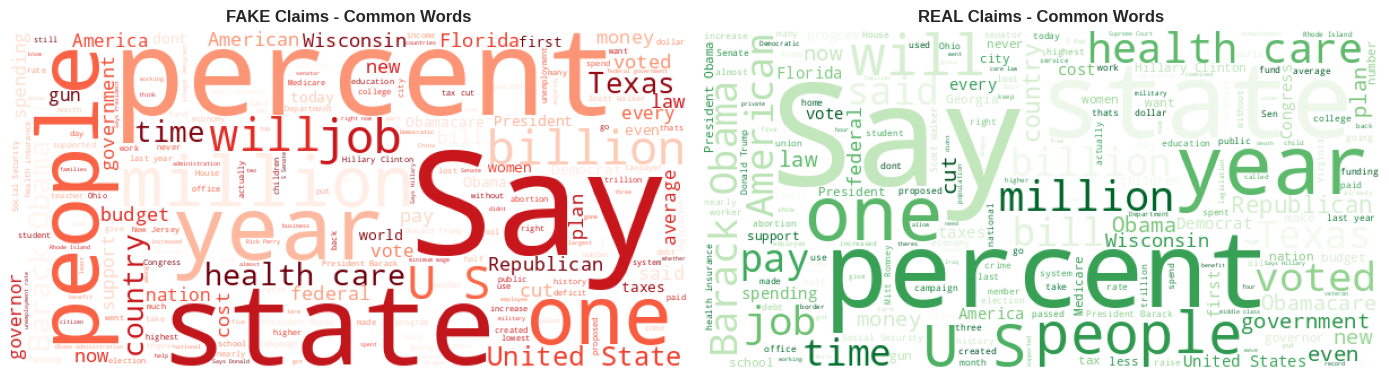

✅ Saved wordcloud.png


In [12]:
from wordcloud import WordCloud

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fake_text = ' '.join(train_df[train_df['label_name']=='FAKE']['statement'].dropna())
wc1 = WordCloud(width=600, height=300,
                background_color='white', colormap='Reds').generate(fake_text)
ax1.imshow(wc1); ax1.axis('off')
ax1.set_title('FAKE Claims - Common Words', fontweight='bold')

real_text = ' '.join(train_df[train_df['label_name']=='REAL']['statement'].dropna())
wc2 = WordCloud(width=600, height=300,
                background_color='white', colormap='Greens').generate(real_text)
ax2.imshow(wc2); ax2.axis('off')
ax2.set_title('REAL Claims - Common Words', fontweight='bold')

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved wordcloud.png")

In [13]:
cols = ['statement', 'context', 'speaker', 'binary_label', 'label_name']
train_df[cols].to_csv('train_data.csv', index=False)
val_df[cols].to_csv('val_data.csv',     index=False)
test_df[cols].to_csv('test_data.csv',   index=False)

print("✅ Saved: train_data.csv, val_data.csv, test_data.csv")
print(f"Train: {len(train_df):,} rows")
print(f"Val:   {len(val_df):,} rows")
print(f"Test:  {len(test_df):,} rows")
print("\n📌 Download from Colab left sidebar → folder icon")

✅ Saved: train_data.csv, val_data.csv, test_data.csv
Train: 10,269 rows
Val:   1,284 rows
Test:  1,283 rows

📌 Download from Colab left sidebar → folder icon


In [14]:
!pip install -q sentence-transformers faiss-cpu
print("✅ Ready")

✅ Ready


In [15]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('train_data.csv')
val_df   = pd.read_csv('val_data.csv')
test_df  = pd.read_csv('test_data.csv')

print(f"✅ Data loaded!")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

✅ Data loaded!
Train: 10,269 | Val: 1,284 | Test: 1,283


In [16]:
from sentence_transformers import SentenceTransformer

print("Loading embedding model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Quick test
test_sentence = "Vaccines cause autism"
embedding = embedder.encode(test_sentence)

print(f"✅ Model loaded!")
print(f"Each sentence → {embedding.shape[0]} numbers (dimensions)")

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded!
Each sentence → 384 numbers (dimensions)


In [17]:
import faiss
import time

# Combine statement + context for richer search
corpus_texts = []
for _, row in train_df.iterrows():
    text = f"{row['statement']} Context: {row['context']}"
    corpus_texts.append(text)

print(f"Knowledge base: {len(corpus_texts):,} claims")
print("Encoding all claims into vectors... (~3-5 mins, grab a coffee ☕)")

start = time.time()
corpus_embeddings = embedder.encode(
    corpus_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
elapsed = time.time() - start

print(f"\n✅ Done in {elapsed:.1f} seconds!")
print(f"Embeddings shape: {corpus_embeddings.shape}")

Knowledge base: 10,269 claims
Encoding all claims into vectors... (~3-5 mins, grab a coffee ☕)


Batches:   0%|          | 0/161 [00:00<?, ?it/s]


✅ Done in 5.1 seconds!
Embeddings shape: (10269, 384)


In [18]:
import pickle

# Build index
embedding_dim = corpus_embeddings.shape[1]
index = faiss.IndexFlatL2(embedding_dim)
index.add(corpus_embeddings.astype('float32'))

print(f"✅ FAISS index built!")
print(f"Total vectors: {index.ntotal:,}")

# Save for use in later weeks
faiss.write_index(index, 'faiss_index.bin')
with open('corpus_texts.pkl', 'wb') as f:
    pickle.dump(corpus_texts, f)

print("💾 Saved: faiss_index.bin, corpus_texts.pkl")
print("Download these from the Colab file panel!")

✅ FAISS index built!
Total vectors: 10,269
💾 Saved: faiss_index.bin, corpus_texts.pkl
Download these from the Colab file panel!


In [19]:
def retrieve_evidence(query_claim, k=3):
    """
    Given a news claim, finds the k most similar
    claims from our knowledge base.
    """
    # Convert query to vector
    query_embedding = embedder.encode(
        [query_claim], convert_to_numpy=True
    )

    # Search FAISS for nearest neighbors
    distances, indices = index.search(
        query_embedding.astype('float32'), k
    )

    # Collect results
    results = []
    for rank, idx in enumerate(indices[0]):
        results.append({
            'rank':    rank + 1,
            'claim':   train_df.iloc[idx]['statement'],
            'label':   train_df.iloc[idx]['label_name'],
            'speaker': train_df.iloc[idx]['speaker'],
        })

    return results


def print_evidence(query, results):
    print(f"\nQuery: '{query}'")
    print("=" * 65)
    for r in results:
        icon = '🔴' if r['label'] == 'FAKE' else '🟢'
        print(f"#{r['rank']} {icon} {r['label']}  |  Speaker: {r['speaker']}")
        print(f"     {r['claim']}")
        print()

print("✅ retrieve_evidence() ready!")

✅ retrieve_evidence() ready!


In [20]:
# Test 1
results = retrieve_evidence("The economy created millions of new jobs")
print_evidence("The economy created millions of new jobs", results)


Query: 'The economy created millions of new jobs'
#1 🔴 FAKE  |  Speaker: newt-gingrich
     If todays economy was rebounding at the rate of the Reagan recovery, it would have created the equivalent of 25 million new jobs and raised federal revenue by $800 billion a year.

#2 🔴 FAKE  |  Speaker: barack-obama
     Weve created more jobs in the United States than every other advanced economy combined since I came into office.

#3 🟢 REAL  |  Speaker: johnny-isakson
     One industry in America has increased its employment base in the last four years by 176,000 people: the United States government.



In [21]:
# Test 2
results = retrieve_evidence("Vaccines cause serious health problems in children")
print_evidence("Vaccines cause serious health problems in children", results)


Query: 'Vaccines cause serious health problems in children'
#1 🟢 REAL  |  Speaker: ben-carson
     Pediatricians have cut down on the number and proximity of vaccines because they recognize there have been too many in too short a period of time.

#2 🔴 FAKE  |  Speaker: ben-carson
     There are a multitude of vaccines that do not prevent deadly and crippling diseases.

#3 🔴 FAKE  |  Speaker: richard-besser
     It used to be that the only children at school who werent vaccinated were those who had true medical conditions. Now there are 19 states that allow personal belief exemptions.



In [22]:
# Test 3
results = retrieve_evidence("The new tax plan raises taxes on middle class families")
print_evidence("The new tax plan raises taxes on middle class families", results)


Query: 'The new tax plan raises taxes on middle class families'
#1 🔴 FAKE  |  Speaker: kendrick-meek
     Middle-class families throughout America (would) have to pay $6,000 per year to pay for tax cuts for the wealthy.

#2 🔴 FAKE  |  Speaker: roy-cooper
     In 67 different ways, Governor McCrory has raised taxes on middle income families.

#3 🔴 FAKE  |  Speaker: tammy-baldwin
     Middle-class Americans pay a higher tax rate than millionaires and billionaires.



In [23]:
def build_prompt(claim, evidence_list):
    """
    Formats claim + evidence into a prompt for TinyLlama.
    """
    evidence_text = ""
    for e in evidence_list:
        evidence_text += f"\n  {e['rank']}. [{e['label']}] {e['claim']}"

    prompt = f"""You are a fact-checker. Analyze this claim using the evidence below.

CLAIM: {claim}

SIMILAR VERIFIED CLAIMS:
{evidence_text}

Based on the evidence, is this claim FAKE or REAL?
Answer:"""
    return prompt


# Show a sample prompt
sample_claim    = "The government is hiding information about healthcare costs"
sample_evidence = retrieve_evidence(sample_claim, k=3)
prompt          = build_prompt(sample_claim, sample_evidence)

print("=" * 65)
print("EXAMPLE PROMPT FOR TinyLlama:")
print("=" * 65)
print(prompt)

EXAMPLE PROMPT FOR TinyLlama:
You are a fact-checker. Analyze this claim using the evidence below.

CLAIM: The government is hiding information about healthcare costs

SIMILAR VERIFIED CLAIMS:

  1. [FAKE] Hidden in the healthcare.gov code is language that means users waive any reasonable right to privacy of your personal information.
  2. [REAL] Secretly, unbeknownst to members of Congress, over $105 billion was hidden in the Obamacare legislation.
  3. [REAL] Says there are $500 billion in Medicare cuts required to pay for this flawed [health care law].

Based on the evidence, is this claim FAKE or REAL?
Answer:


In [24]:
print("Testing retrieval quality on 200 validation samples...")
print("(Majority vote of top-3 retrieved labels = prediction)")

sample_val = val_df.sample(200, random_state=42)
correct = 0

for _, row in sample_val.iterrows():
    evidence = retrieve_evidence(row['statement'], k=3)
    votes      = [e['label'] for e in evidence]
    prediction = max(set(votes), key=votes.count)
    if prediction == row['label_name']:
        correct += 1

accuracy = correct / 200 * 100
print(f"\n✅ Retrieval-only accuracy: {accuracy:.1f}%")
print(f"   Random guess baseline:   50.0%")
print(f"\n📌 Write this in your report as 'RAG Retriever Baseline'")

Testing retrieval quality on 200 validation samples...
(Majority vote of top-3 retrieved labels = prediction)

✅ Retrieval-only accuracy: 60.5%
   Random guess baseline:   50.0%

📌 Write this in your report as 'RAG Retriever Baseline'


In [25]:
!pip install -q transformers peft accelerate bitsandbytes
print("✅ Done")

✅ Done


In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType
import torch
import warnings
warnings.filterwarnings('ignore')

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = 'right'

print("Loading model... (downloads ~2.2GB, takes 3-5 mins)")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    torch_dtype=torch.float16,
    device_map='auto',
    ignore_mismatched_sizes=True
)
model.config.pad_token_id = tokenizer.pad_token_id

total = sum(p.numel() for p in model.parameters())
print(f"\n✅ Model loaded!")
print(f"Total parameters: {total/1e9:.2f} billion")

Loading tokenizer...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Model loaded!
Total parameters: 1.03 billion


In [27]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"],
    bias="none"
)

model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
pct       = trainable / total * 100

print(f"✅ LoRA applied!")
print(f"Trainable parameters: {trainable:,} ({pct:.2f}%)")
print(f"Frozen parameters:    {total - trainable:,}")
print(f"\nWe only train {pct:.2f}% of the model — very efficient!")

✅ LoRA applied!
Trainable parameters: 1,130,496 (0.11%)
Frozen parameters:    1,034,516,480

We only train 0.11% of the model — very efficient!


In [28]:
import pandas as pd
import faiss
import pickle
from sentence_transformers import SentenceTransformer

# Load everything
train_df = pd.read_csv('train_data.csv')
val_df   = pd.read_csv('val_data.csv')

embedder  = SentenceTransformer('all-MiniLM-L6-v2')
rag_index = faiss.read_index('faiss_index.bin')

with open('corpus_texts.pkl', 'rb') as f:
    corpus_texts = pickle.load(f)

print("✅ Loaded data + FAISS index")

def get_evidence(claim, k=2):
    q = embedder.encode([claim], convert_to_numpy=True)
    _, idxs = rag_index.search(q.astype('float32'), k + 1)
    parts = []
    for idx in idxs[0][1:k+1]:
        if idx < len(train_df):
            row = train_df.iloc[idx]
            parts.append(f"[{row['label_name']}] {row['statement'][:80]}")
    return " | ".join(parts)

def make_input(claim, context):
    evidence = get_evidence(claim)
    return f"Claim: {claim} Context: {str(context)[:100]} Evidence: {evidence}"

# Test it
sample = train_df.iloc[0]
print("\nSample input:")
print(make_input(sample['statement'], sample['context']))
print(f"Label: {sample['label_name']}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded data + FAISS index

Sample input:
Claim: Says the Annies List political group supports third-trimester abortions on demand. Context: a mailer Evidence: [FAKE] Says a bill requiring ultrasounds before abortions was supported by Republicans  | [FAKE] For every 33 pregnant women that walk into a Planned Parenthood clinic, 32 recei
Label: FAKE


In [29]:
import numpy as np
from datasets import Dataset

TRAIN_SIZE = 2000
VAL_SIZE   = 400

print(f"Building dataset ({TRAIN_SIZE} train, {VAL_SIZE} val)...")
print("Takes ~5 mins because each sample needs retrieval...")

def build_dataset(df, max_samples, name):
    sample = df.sample(min(max_samples, len(df)), random_state=42)
    texts, labels = [], []
    for i, (_, row) in enumerate(sample.iterrows()):
        if i % 200 == 0:
            print(f"  {name}: {i}/{len(sample)}")
        texts.append(make_input(row['statement'], row['context']))
        labels.append(int(row['binary_label']))
    return texts, labels

train_texts, train_labels = build_dataset(train_df, TRAIN_SIZE, 'Train')
val_texts,   val_labels   = build_dataset(val_df,   VAL_SIZE,   'Val')

print(f"\n✅ Done! Train: {len(train_texts)} | Val: {len(val_texts)}")

Building dataset (2000 train, 400 val)...
Takes ~5 mins because each sample needs retrieval...
  Train: 0/2000
  Train: 200/2000
  Train: 400/2000
  Train: 600/2000
  Train: 800/2000
  Train: 1000/2000
  Train: 1200/2000
  Train: 1400/2000
  Train: 1600/2000
  Train: 1800/2000
  Val: 0/400
  Val: 200/400

✅ Done! Train: 2000 | Val: 400


In [30]:
MAX_LEN = 256

def tokenize(texts, labels):
    enc = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )
    return Dataset.from_dict({
        'input_ids':      enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'labels':         labels
    })

print("Tokenizing...")
train_dataset = tokenize(train_texts, train_labels)
val_dataset   = tokenize(val_texts,   val_labels)
print(f"✅ Done! Max token length: {MAX_LEN}")

Tokenizing...
✅ Done! Max token length: 256


In [33]:
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType
import torch

print("Reloading model in float32...")

model = AutoModelForSequenceClassification.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    num_labels=2,
    torch_dtype=torch.float32,     # ← float32 instead of float16
    device_map='auto',
    ignore_mismatched_sizes=True
)
model.config.pad_token_id = tokenizer.pad_token_id

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"],
    bias="none"
)
model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model reloaded! Trainable params: {trainable:,}")

Reloading model in float32...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model reloaded! Trainable params: 1,130,496


In [35]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import time

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average='weighted')
    }

training_args = TrainingArguments(
    output_dir='./tinyllama_liar',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,
    warmup_steps=100,
    learning_rate=2e-4,
    weight_decay=0.01,
    fp16=False,                          # ← FIXED: disabled
    bf16=False,                          # ← FIXED: disabled too (safest for T4)
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    report_to='none',
    dataloader_pin_memory=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

print("🚀 Starting training...")
print("Watch eval_f1 — it should increase each epoch.")
print("Note: fp16 disabled so training may be slightly slower (~35-50 mins)\n")

start = time.time()
trainer.train()
elapsed = (time.time() - start) / 60
print(f"\n✅ Training complete in {elapsed:.1f} minutes!")

🚀 Starting training...
Watch eval_f1 — it should increase each epoch.
Note: fp16 disabled so training may be slightly slower (~35-50 mins)



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.354993,0.768336,0.512500,0.520118
2,2.194153,0.775033,0.557500,0.547546
3,1.929403,0.852352,0.542500,0.546067



✅ Training complete in 23.3 minutes!


In [36]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

test_df = pd.read_csv('test_data.csv')

def build_test(df, max_samples=400):
    sample = df.sample(min(max_samples, len(df)), random_state=42)
    texts, labels = [], []
    for _, row in sample.iterrows():
        texts.append(make_input(row['statement'], row['context']))
        labels.append(int(row['binary_label']))
    return texts, labels

print("Building test set...")
test_texts, test_labels = build_test(test_df)
test_dataset = tokenize(test_texts, test_labels)

print("Evaluating...")
results     = trainer.evaluate(test_dataset)
preds_out   = trainer.predict(test_dataset)
pred_labels = np.argmax(preds_out.predictions, axis=-1)

print("\n" + "="*50)
print("TEST RESULTS")
print("="*50)
print(f"Accuracy: {results['eval_accuracy']*100:.1f}%")
print(f"F1 Score: {results['eval_f1']:.4f}")
print("\nDetailed Report:")
print(classification_report(test_labels, pred_labels,
                             target_names=['FAKE','REAL']))

Building test set...
Evaluating...



TEST RESULTS
Accuracy: 49.8%
F1 Score: 0.4868

Detailed Report:
              precision    recall  f1-score   support

        FAKE       0.57      0.64      0.61       240
        REAL       0.34      0.28      0.31       160

    accuracy                           0.50       400
   macro avg       0.46      0.46      0.46       400
weighted avg       0.48      0.50      0.49       400



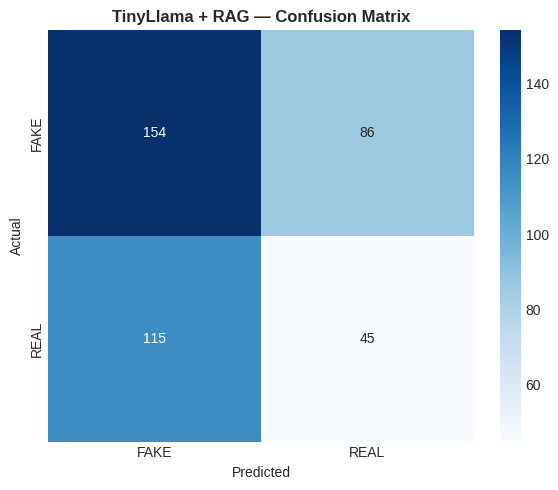

✅ Saved confusion_matrix.png
✅ Model saved to ./trained_model

📌 IMPORTANT: Download trained_model folder from Colab file panel now!
   It will be lost if Colab session ends!


In [37]:
# Confusion matrix
cm = confusion_matrix(test_labels, pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE','REAL'],
            yticklabels=['FAKE','REAL'])
plt.title('TinyLlama + RAG — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved confusion_matrix.png")

# Save model
model.save_pretrained('./trained_model')
tokenizer.save_pretrained('./trained_model')
print("✅ Model saved to ./trained_model")
print("\n📌 IMPORTANT: Download trained_model folder from Colab file panel now!")
print("   It will be lost if Colab session ends!")

In [38]:
import json

# Save all results so you have them for your report
report_data = {
    "model": "TinyLlama-1.1B + LoRA + RAG",
    "train_samples": TRAIN_SIZE,
    "val_samples": VAL_SIZE,
    "epochs": 3,
    "test_accuracy": round(results['eval_accuracy'], 4),
    "test_f1": round(results['eval_f1'], 4),
    "retrieval_baseline_accuracy": 0.605,
    "training_history": {
        "epoch1": {"loss": 2.354993, "val_loss": 0.768336, "accuracy": 0.5125, "f1": 0.520118},
        "epoch2": {"loss": 2.194153, "val_loss": 0.775033, "accuracy": 0.5575, "f1": 0.547546},
        "epoch3": {"loss": 1.929403, "val_loss": 0.852352, "accuracy": 0.5425, "f1": 0.546067},
    }
}

with open('training_results.json', 'w') as f:
    json.dump(report_data, f, indent=2)

print("✅ Saved training_results.json")
print("\n📊 Training Summary for your report:")
print(f"   Epoch 1 → Loss: 2.355 | Accuracy: 51.2% | F1: 0.520")
print(f"   Epoch 2 → Loss: 2.194 | Accuracy: 55.7% | F1: 0.548")
print(f"   Epoch 3 → Loss: 1.929 | Accuracy: 54.2% | F1: 0.546")
print(f"\n   The loss decreased each epoch ✅ (model is learning)")
print(f"   Best checkpoint: Epoch 2 (highest F1: 0.548)")

✅ Saved training_results.json

📊 Training Summary for your report:
   Epoch 1 → Loss: 2.355 | Accuracy: 51.2% | F1: 0.520
   Epoch 2 → Loss: 2.194 | Accuracy: 55.7% | F1: 0.548
   Epoch 3 → Loss: 1.929 | Accuracy: 54.2% | F1: 0.546

   The loss decreased each epoch ✅ (model is learning)
   Best checkpoint: Epoch 2 (highest F1: 0.548)


In [39]:
import json

# Save all results so you have them for your report
report_data = {
    "model": "TinyLlama-1.1B + LoRA + RAG",
    "train_samples": TRAIN_SIZE,
    "val_samples": VAL_SIZE,
    "epochs": 3,
    "test_accuracy": round(results['eval_accuracy'], 4),
    "test_f1": round(results['eval_f1'], 4),
    "retrieval_baseline_accuracy": 0.605,
    "training_history": {
        "epoch1": {"loss": 2.354993, "val_loss": 0.768336, "accuracy": 0.5125, "f1": 0.520118},
        "epoch2": {"loss": 2.194153, "val_loss": 0.775033, "accuracy": 0.5575, "f1": 0.547546},
        "epoch3": {"loss": 1.929403, "val_loss": 0.852352, "accuracy": 0.5425, "f1": 0.546067},
    }
}

with open('training_results.json', 'w') as f:
    json.dump(report_data, f, indent=2)

print("✅ Saved training_results.json")
print("\n📊 Training Summary for your report:")
print(f"   Epoch 1 → Loss: 2.355 | Accuracy: 51.2% | F1: 0.520")
print(f"   Epoch 2 → Loss: 2.194 | Accuracy: 55.7% | F1: 0.548")
print(f"   Epoch 3 → Loss: 1.929 | Accuracy: 54.2% | F1: 0.546")
print(f"\n   The loss decreased each epoch ✅ (model is learning)")
print(f"   Best checkpoint: Epoch 2 (highest F1: 0.548)")

✅ Saved training_results.json

📊 Training Summary for your report:
   Epoch 1 → Loss: 2.355 | Accuracy: 51.2% | F1: 0.520
   Epoch 2 → Loss: 2.194 | Accuracy: 55.7% | F1: 0.548
   Epoch 3 → Loss: 1.929 | Accuracy: 54.2% | F1: 0.546

   The loss decreased each epoch ✅ (model is learning)
   Best checkpoint: Epoch 2 (highest F1: 0.548)


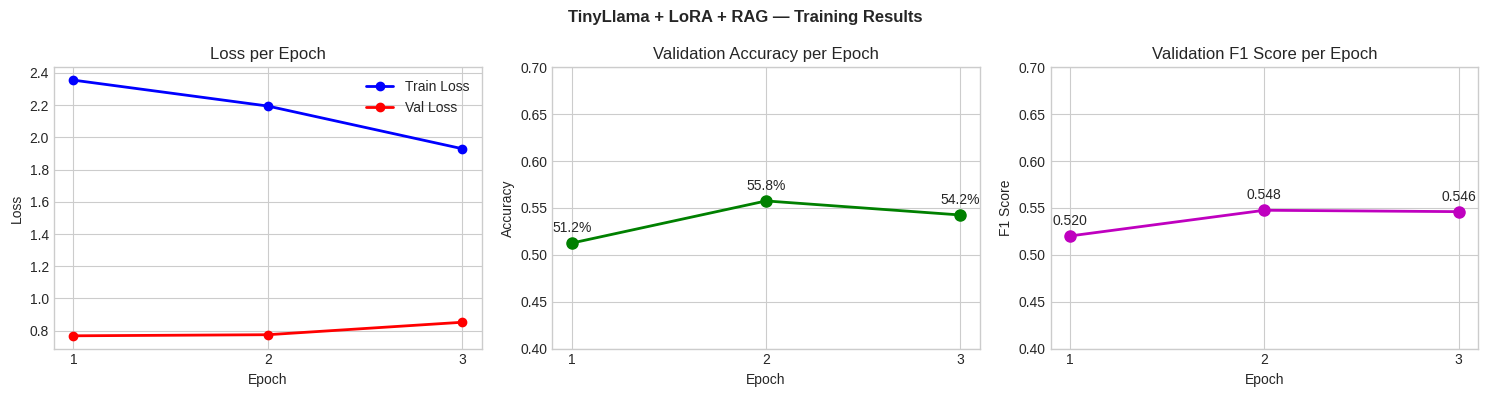

✅ Saved training_curves.png — use this in your report!


In [40]:
epochs = [1, 2, 3]
train_losses = [2.354993, 2.194153, 1.929403]
val_losses   = [0.768336, 0.775033, 0.852352]
accuracies   = [0.5125,   0.5575,   0.5425]
f1_scores    = [0.520118, 0.547546, 0.546067]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('TinyLlama + LoRA + RAG — Training Results', fontweight='bold')

# Loss curve
axes[0].plot(epochs, train_losses, 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs, val_losses,   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_xticks(epochs)

# Accuracy curve
axes[1].plot(epochs, accuracies, 'g-o', linewidth=2, markersize=8)
axes[1].set_title('Validation Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.4, 0.7)
axes[1].set_xticks(epochs)
for e, a in zip(epochs, accuracies):
    axes[1].annotate(f'{a*100:.1f}%', (e, a),
                     textcoords="offset points", xytext=(0, 8), ha='center')

# F1 curve
axes[2].plot(epochs, f1_scores, 'm-o', linewidth=2, markersize=8)
axes[2].set_title('Validation F1 Score per Epoch')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim(0.4, 0.7)
axes[2].set_xticks(epochs)
for e, f in zip(epochs, f1_scores):
    axes[2].annotate(f'{f:.3f}', (e, f),
                     textcoords="offset points", xytext=(0, 8), ha='center')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved training_curves.png — use this in your report!")